Load necessary dependencies.

In [22]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.odr import ODR, Model, Data
import matplotlib.pyplot as plt

Load data.

In [23]:
beams_data = np.loadtxt('beams.csv', delimiter=',', skiprows=1)

X = beams_data[:, 0]  # Specific Gravity
y = beams_data[:, 1]  # Strength

**Problem 3**

a) Fit and run ordinary least squares model.

In [24]:
simple_model = LinearRegression().fit(X.reshape(-1, 1), y)
print(f"Prediction at Specific Gravity 0.590: {simple_model.predict([[0.590]])[0]}")

Prediction at Specific Gravity 0.590: 12.903712789598174


Using closed form to do ordinary least squares.

In [25]:
sxx = np.sum((X - np.mean(X))**2)
sxy = np.sum((X - np.mean(X)) * (y - np.mean(y)))
beta1ols = sxy / sxx
beta0ols = np.mean(y) - beta1ols * np.mean(X)
print(f"Prediction at Specific Gravity 0.590: {beta1ols * 0.590 + beta0ols}")

Prediction at Specific Gravity 0.590: 12.903712789598174


b) Fit and run an orthogonal least squares model (Orthogonal Distance Regression).

In [26]:
def linear_model(B, x):
    return B[0] * x + B[1]

model = Model(linear_model)
data = Data(X, y)

odr = ODR(data, model, beta0=[1.0, 0.0])
param = odr.run().beta
print(f"Prediction at Specific Gravity 0.590: {param[0] * 0.590 + param[1]}")

Prediction at Specific Gravity 0.590: 13.107093827127159


Using closed form to do orthogonal least squares.

In [27]:
sxx = np.sum((X - np.mean(X))**2)
sxy = np.sum((X - np.mean(X)) * (y - np.mean(y)))
syy = np.sum((y - np.mean(y))**2)

beta1odr = ((syy - sxx) + np.sqrt((syy - sxx)**2 + 4 * sxy**2)) / (2 * sxy)
beta0odr = np.mean(y) - beta1odr * np.mean(X)

print(f"Prediction at Specific Gravity 0.590: {beta1odr * 0.590 + beta0odr}")

Prediction at Specific Gravity 0.590: 13.107093620833423


c) Fit and run an Errors in Variables model.

In [28]:
eiv_data = Data(X, y, wd=1.0/0.01, we=1.0/1)
eiv_obj = ODR(eiv_data, model, beta0=[1.0, 0.0])
eiv_parameters = eiv_obj.run().beta

print(f"Prediction at Specific Gravity 0.590: {eiv_parameters[0] * 0.590 + eiv_parameters[1]}")

Prediction at Specific Gravity 0.590: 13.019673997367835


Using closed form to do error in variables.

In [29]:
lam = 0.01
sxx = np.sum((X - np.mean(X))**2)
sxy = np.sqrt(lam) * np.sum((X - np.mean(X)) * (y - np.mean(y)))
syy = lam * np.sum((y - np.mean(y))**2)

beta1eiv = ((syy - sxx) + np.sqrt((syy - sxx)**2 + 4 * sxy**2)) / (2 * sxy)
beta0eiv = np.mean(np.sqrt(lam) * y) - beta1eiv * np.mean(X)

beta1eiv = beta1eiv / np.sqrt(lam)
beta0eiv = beta0eiv / np.sqrt(lam)

print(f"Prediction at Specific Gravity 0.590: {beta1eiv * 0.590 + beta0eiv}")

Prediction at Specific Gravity 0.590: 13.01968259719115


Regression Comparison Plot.

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_23035/3309222141.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x_plot, beta1eiv * x_plot + beta0eiv, label=f'Errors-in-Variables ($\lambda={lam:.4f}$)', color='red', linewidth=2)


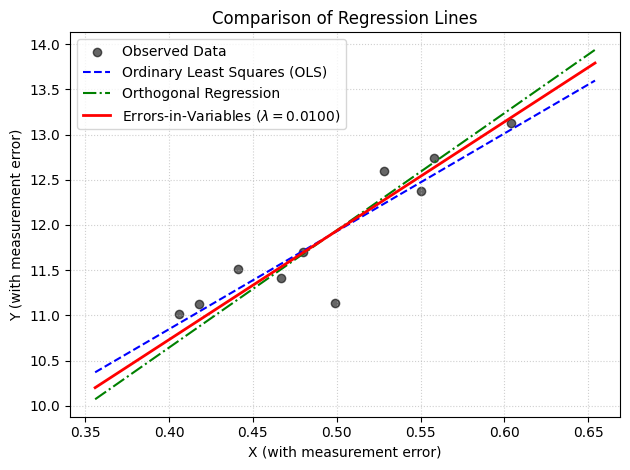

In [ ]:
x_plot = np.linspace(min(X) - 0.05, max(X) + 0.05, 100)
plt.scatter(X, y, color='black', alpha=0.6, label='Observed Data')
plt.plot(x_plot, beta1ols * x_plot + beta0ols, label='Ordinary Least Squares (OLS)', color='blue', linestyle='--')
plt.plot(x_plot, beta1odr* x_plot + beta0odr, label='Orthogonal Regression', color='green', linestyle='-.')
plt.plot(x_plot, beta1eiv * x_plot + beta0eiv, label=f'Errors-in-Variables ($\lambda={lam:.4f}$)', color='red', linewidth=2)

plt.title('Comparison of Regression Lines')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('regression_comparison.png', dpi=300)